<a href="https://colab.research.google.com/github/Kaviyasree-N/ML-PROJECT/blob/main/url_detect_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!
Dataset shape: (101219, 18)

First 5 rows:
                                               URL  url_length  \
0  https://keraekken-loagginnusa.godaddysites.com/          47   
1         https://metamsk01lgiix.godaddysites.com/          40   
2                          http://myglobaltech.in/          23   
3                   http://djtool-for-spotify.com/          30   
4  https://scearmcoommunnlty.com/invent/freind/get          47   

   has_ip_address  dot_count  https_flag  url_entropy  token_count  \
0               0          2           1     4.250669            6   
1               0          2           1     4.196439            6   
2               0          1           0     3.936180            5   
3               0          1           0     3.894740            5   
4               0          1           1     4.143127            7   

   subdomain_count  query_param_count  tld_length  path_length  \
0                1                  1       

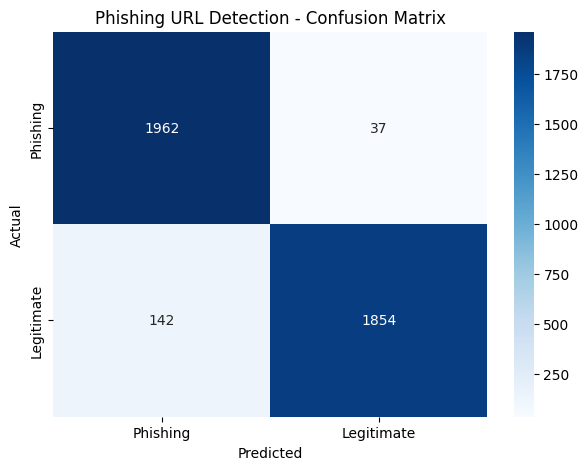

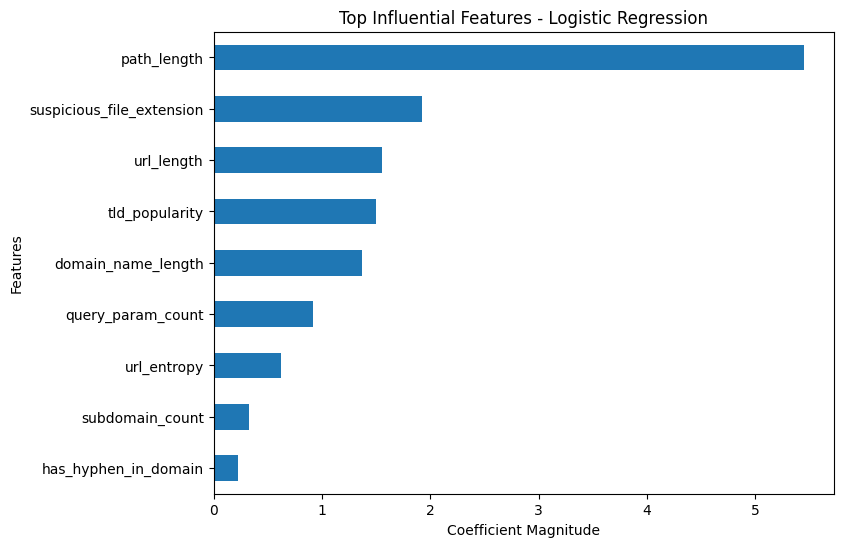


5-FOLD CROSS VALIDATION
F1 Scores: [0.96317136 0.95676788 0.95556126 0.96335878 0.95      ]
Average F1: 0.9578

URL PREDICTION TEST
URL: https://leetcode.com/
Prediction: Legitimate
Confidence: 100.0 %

MODEL SAVING
Saved: phishing_logistic_model.pkl
Saved: url_scaler.pkl

FILE VERIFICATION
phishing_logistic_model.pkl: True
url_scaler.pkl: True

Phishing URL detection model completed!


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# PHISHING URL DETECTION USING LOGISTIC REGRESSION
# ============================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.pipeline import Pipeline


# -----------------------------
# 2. Load Dataset
# -----------------------------

df = pd.read_csv("Phishing_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())


# -----------------------------
# 3. Separate Phishing and
#    Legitimate URLs
# -----------------------------

# ClassLabel:
# 0 = Phishing
# 1 = Legitimate

df_phishing = df[df["ClassLabel"] == 0]
df_legit = df[df["ClassLabel"] == 1]

print("\nOriginal class distribution:")
print("Phishing:", len(df_phishing))
print("Legitimate:", len(df_legit))


# -----------------------------
# 4. Create Balanced Dataset
# -----------------------------

df_phishing_small = df_phishing.sample(
    n=10000,
    random_state=42
)

df_legit_small = df_legit.sample(
    n=10000,
    random_state=42
)

df_balanced = pd.concat(
    [df_phishing_small, df_legit_small]
)

# Shuffle dataset
df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nBalanced dataset shape:")
print(df_balanced.shape)

print("\nBalanced class distribution:")
print(df_balanced["ClassLabel"].value_counts())


# -----------------------------
# 5. Remove Duplicates
#    and Missing Values
# -----------------------------

df_balanced = df_balanced.drop_duplicates()

df_balanced = df_balanced.fillna(0)

print("\nDataset after cleaning:")
print(df_balanced.shape)


# -----------------------------
# 6. Select Features
# -----------------------------

# Features that are not being used
drop_features = [
    "https_flag",
    "percentage_numeric_chars",
    "token_count",
    "has_ip_address",
    "number_of_digits",
    "dot_count",
    "tld_length"
]

# Create X and y
X = df_balanced.drop(
    ["URL", "ClassLabel"] + drop_features,
    axis=1
)

y = df_balanced["ClassLabel"]

print("\nFeatures used:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])


# -----------------------------
# 7. Train/Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# -----------------------------
# 8. Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# -----------------------------
# 9. Train Logistic Regression
# -----------------------------

model = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("\nLogistic Regression model trained successfully!")


# -----------------------------
# 10. Test Model
# -----------------------------

y_pred = model.predict(
    X_test_scaled
)


# -----------------------------
# 11. Calculate Performance
# -----------------------------

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=1
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=1
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=1
)

print("\n================================")
print("MODEL PERFORMANCE")
print("================================")

print(
    "Accuracy :", round(accuracy * 100, 2), "%"
)

print(
    "Precision:", round(precision * 100, 2), "%"
)

print(
    "Recall   :", round(recall * 100, 2), "%"
)

print(
    "F1 Score :", round(f1 * 100, 2), "%"
)


# -----------------------------
# 12. Classification Report
# -----------------------------

print("\n================================")
print("CLASSIFICATION REPORT")
print("================================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Phishing",
            "Legitimate"
        ]
    )
)


# -----------------------------
# 13. Confusion Matrix
# -----------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Phishing",
        "Legitimate"
    ],
    yticklabels=[
        "Phishing",
        "Legitimate"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Phishing URL Detection - Confusion Matrix"
)

plt.show()


# -----------------------------
# 14. Feature Importance
# -----------------------------

coefficients = model.coef_[0]

feature_importances = pd.Series(
    coefficients,
    index=X.columns
)

top_features = (
    feature_importances
    .abs()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(8, 6))

top_features.plot(
    kind="barh"
)

plt.title(
    "Top Influential Features - Logistic Regression"
)

plt.xlabel(
    "Coefficient Magnitude"
)

plt.ylabel(
    "Features"
)

plt.show()


# -----------------------------
# 15. 5-Fold Cross Validation
# -----------------------------

cv_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            random_state=42
        )
    )
])

scores = cross_val_score(
    cv_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("\n================================")
print("5-FOLD CROSS VALIDATION")
print("================================")

print("F1 Scores:", scores)

print(
    "Average F1:",
    round(scores.mean(), 4)
)


# -----------------------------
# 16. URL Feature Extraction
# -----------------------------

def extract_features(url):

    url = str(url).strip()

    features = {}

    # URL length
    features["url_length"] = len(url)

    # URL entropy
    if len(url) > 0:

        probs = [
            url.count(c) / len(url)
            for c in set(url)
        ]

        features["url_entropy"] = -sum(
            p * np.log2(p)
            for p in probs
            if p > 0
        )

    else:

        features["url_entropy"] = 0

    # Domain
    try:

        if "://" in url:
            domain = url.split("/")[2]
        else:
            domain = url.split("/")[0]

    except:

        domain = ""


    # Subdomain count
    domain_parts = domain.split(".")

    if len(domain_parts) > 2:

        features["subdomain_count"] = (
            len(domain_parts) - 2
        )

    else:

        features["subdomain_count"] = 0


    # Query parameter count
    if "?" in url:

        query_part = url.split("?", 1)[1]

        if query_part.strip() == "":
            features["query_param_count"] = 0

        else:
            features["query_param_count"] = (
                len(query_part.split("&"))
            )

    else:

        features["query_param_count"] = 0


    # Path length
    try:

        if "://" in url:

            parts = url.split("/", 3)

            if len(parts) == 4:
                path = "/" + parts[3]
            else:
                path = ""

        else:

            parts = url.split("/", 1)

            if len(parts) == 2:
                path = "/" + parts[1]
            else:
                path = ""

        features["path_length"] = len(path)

    except:

        features["path_length"] = 0


    # Hyphen in domain
    features["has_hyphen_in_domain"] = (
        1 if "-" in domain else 0
    )


    # TLD popularity
    try:

        tld = domain.split(".")[-1]

        # Using TLD length as the value
        # because this is how the feature
        # is represented in the model dataset
        features["tld_popularity"] = len(tld)

    except:

        features["tld_popularity"] = 0


    # Suspicious file extension
    suspicious_extensions = [
        ".exe",
        ".zip",
        ".js",
        ".php",
        ".scr"
    ]

    features["suspicious_file_extension"] = (
        1
        if any(
            url.lower().endswith(ext)
            for ext in suspicious_extensions
        )
        else 0
    )


    # Domain name length
    features["domain_name_length"] = len(domain)


    # IMPORTANT:
    # Keep exactly the same order
    # used during model training.

    feature_order = [
        "url_length",
        "url_entropy",
        "subdomain_count",
        "query_param_count",
        "path_length",
        "has_hyphen_in_domain",
        "tld_popularity",
        "suspicious_file_extension",
        "domain_name_length"
    ]

    return np.array([
        features[column]
        for column in feature_order
    ]).reshape(1, -1)


# -----------------------------
# 17. Prediction Function
# -----------------------------

def predict_url(url):

    # Extract URL features
    features = extract_features(url)

    # Scale features
    features_scaled = scaler.transform(
        features
    )

    # Prediction
    prediction = model.predict(
        features_scaled
    )[0]

    # Prediction probabilities
    probabilities = model.predict_proba(
        features_scaled
    )[0]

    # Confidence
    confidence = max(probabilities) * 100


    # Convert class number
    if prediction == 0:

        result = "Phishing"

    else:

        result = "Legitimate"


    return {
        "url": url,
        "prediction": result,
        "confidence": round(
            confidence,
            2
        )
    }


# -----------------------------
# 18. Test Prediction
# -----------------------------

test_url = "https://leetcode.com/"

result = predict_url(
    test_url
)

print("\n================================")
print("URL PREDICTION TEST")
print("================================")

print("URL:", result["url"])

print(
    "Prediction:",
    result["prediction"]
)

print(
    "Confidence:",
    result["confidence"],
    "%"
)


# -----------------------------
# 19. Save Model
# -----------------------------

joblib.dump(
    model,
    "phishing_logistic_model.pkl"
)

joblib.dump(
    scaler,
    "url_scaler.pkl"
)

print("\n================================")
print("MODEL SAVING")
print("================================")

print(
    "Saved: phishing_logistic_model.pkl"
)

print(
    "Saved: url_scaler.pkl"
)


# -----------------------------
# 20. Verify Saved Files
# -----------------------------

import os

print("\n================================")
print("FILE VERIFICATION")
print("================================")

print(
    "phishing_logistic_model.pkl:",
    os.path.exists(
        "phishing_logistic_model.pkl"
    )
)

print(
    "url_scaler.pkl:",
    os.path.exists(
        "url_scaler.pkl"
    )
)

print("\nPhishing URL detection model completed!")